# 13-07-2026 K-Means Clustering
## Energy Consumption Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:
uploaded=files.upload()
filename=list(uploaded.keys())[0]
df=pd.read_csv(filename)

df.head()

Saving energy_data.csv to energy_data.csv


,timestamp,location,energy_consumption,temperature
0,01-01-2023 00:00,Industrial,139.101364,33.820542
1,01-01-2023 01:00,Residential,247.109808,26.392602
2,01-01-2023 02:00,Industrial,233.934693,25.027439
3,01-01-2023 03:00,Industrial,243.013532,27.107712
4,01-01-2023 04:00,Residential,313.502582,27.326153


## Generalisations

- Each row represents an energy observation.
- Dataset contains timestamp, location, temperature and energy consumption.
- Goal is to identify similar energy consumption patterns using K-Means clustering.


In [3]:
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print("Duplicate Rows:",df.duplicated().sum())

          timestamp     location  energy_consumption  temperature
0  01-01-2023 00:00   Industrial          139.101364    33.820542
1  01-01-2023 01:00  Residential          247.109808    26.392602
2  01-01-2023 02:00   Industrial          233.934693    25.027439
3  01-01-2023 03:00   Industrial          243.013532    27.107712
4  01-01-2023 04:00  Residential          313.502582    27.326153
(10000, 4)
Index(['timestamp', 'location', 'energy_consumption', 'temperature'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           10000 non-null  object 
 1   location            10000 non-null  object 
 2   energy_consumption  10000 non-null  float64
 3   temperature         10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB
None
       energy_consumption   temperature
count  

In [4]:
df["timestamp"]=pd.to_datetime(df["timestamp"],dayfirst=True,errors="coerce")

df["Hour"]=df["timestamp"].dt.hour

df["Month"]=df["timestamp"].dt.month

encoder=LabelEncoder()

df["location"]=encoder.fit_transform(df["location"])

df.fillna(df.select_dtypes(include=np.number).median(),inplace=True)

df.head()

,timestamp,location,energy_consumption,temperature,Hour,Month
0,2023-01-01 00:00:00,1,139.101364,33.820542,0,1
1,2023-01-01 01:00:00,2,247.109808,26.392602,1,1
2,2023-01-01 02:00:00,1,233.934693,25.027439,2,1
3,2023-01-01 03:00:00,1,243.013532,27.107712,3,1
4,2023-01-01 04:00:00,2,313.502582,27.326153,4,1


## Feature Relationships

- Temperature influences energy consumption.
- Different locations consume different amounts of energy.
- Hour of the day may affect energy demand.


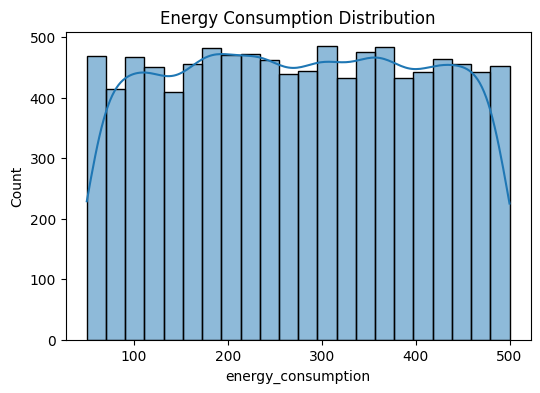

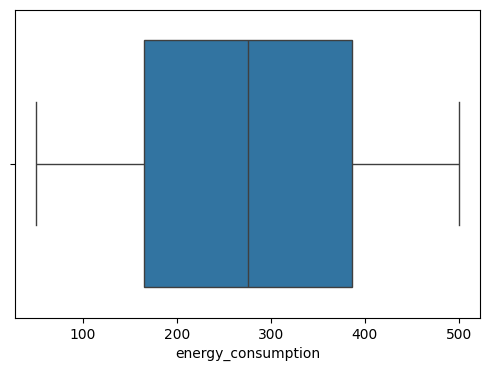

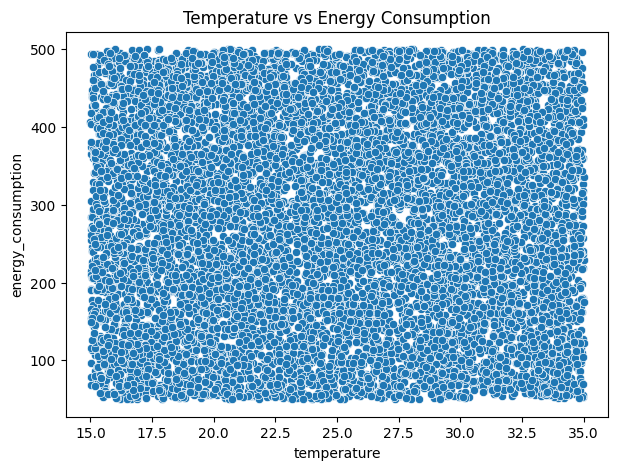

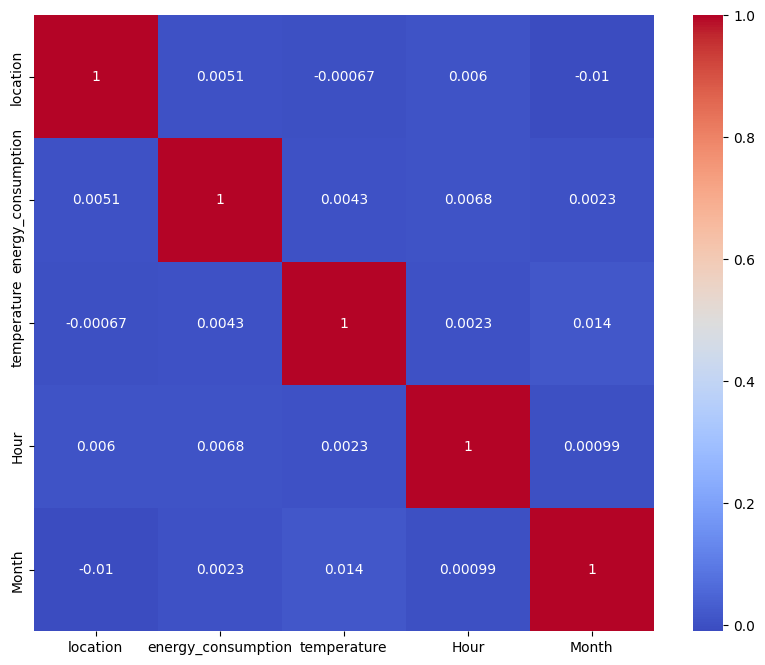

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df["energy_consumption"],kde=True)
plt.title("Energy Consumption Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["energy_consumption"])
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(data=df,x="temperature",y="energy_consumption")
plt.title("Temperature vs Energy Consumption")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap="coolwarm")
plt.show()


In [10]:
X=df[["location","temperature","energy_consumption","Hour"]]

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)


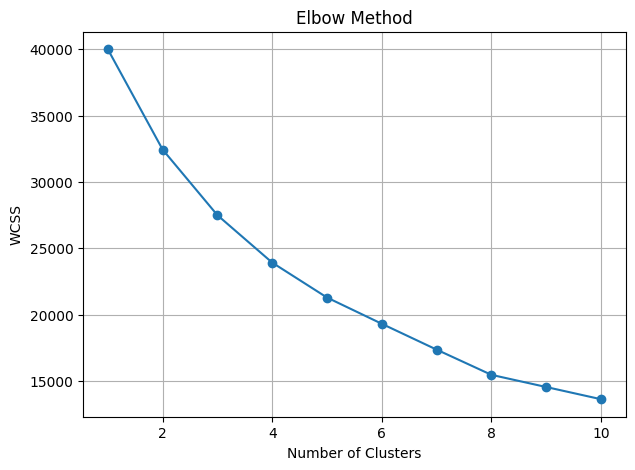

In [7]:
wcss=[]

for i in range(1,11):
    model=KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()


In [8]:
best_k=3

kmeans=KMeans(
    n_clusters=best_k,
    init="k-means++",
    random_state=42,
    n_init=10
)

df["Cluster"]=kmeans.fit_predict(X_scaled)

score=silhouette_score(X_scaled,df["Cluster"])

print("Silhouette Score:",round(score,3))


Silhouette Score: 0.187


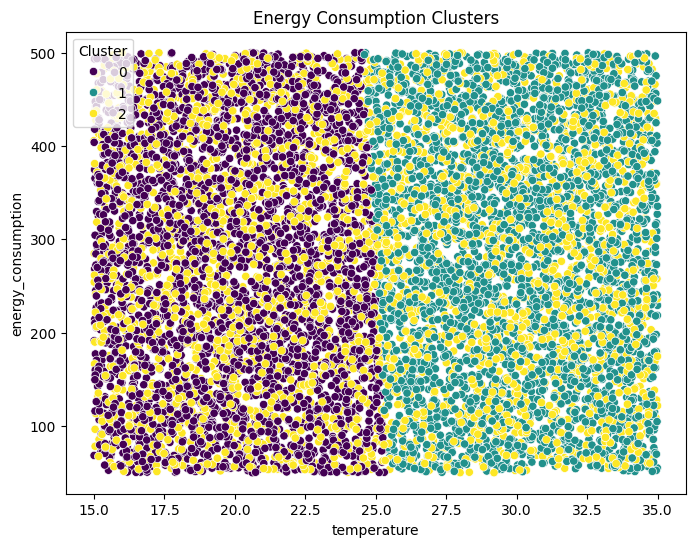

         location  energy_consumption  temperature       Hour     Month
Cluster                                                                
0        1.504667          271.013013    19.988712  11.533574  5.882264
1        1.503601          280.563505    29.995705  11.495798  5.854142
2        0.000000          274.626891    24.972232  11.451748  5.934568
Cluster
2    3347
1    3332
0    3321
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="temperature",
    y="energy_consumption",
    hue="Cluster",
    palette="viridis"
)

plt.title("Energy Consumption Clusters")
plt.show()

print(df.groupby("Cluster").mean(numeric_only=True))
print(df["Cluster"].value_counts())

df.to_csv("clustered_energy_data.csv",index=False)


## Conclusion

- Imported and analysed the dataset.
- Converted timestamp into Hour and Month features.
- Encoded location using LabelEncoder.
- Applied StandardScaler.
- Used the Elbow Method to determine the optimal number of clusters.
- Performed K-Means clustering.
- Evaluated the clustering using the Silhouette Score.
- Visualised the resulting clusters.
